## Tactical Analysis: "The Calm Before The Storm"

This visualization provides a deep dive into Riyad Mahrez's creative influence against Bournemouth, highlighting the "Soft Density" of his world-class spatial awareness:

* **The Golden Wing (Right Flank):** The high-intensity blue zones are concentrated on the right offensive wing. This was Mahrez's "office," where he consistently received the ball to initiate penetrative runs or deliver precision crosses.
* **Inverted Winger Role (Cutting Inside):** The map brilliantly illustrates that Mahrez was not a traditional touchline winger. The color gradients extending toward the central "Zone 14" and the penalty box showcase his elite ability to drag defenders out of position, creating space for teammates or shooting opportunities.
* **Tactical Balance & Discipline:** The soft blue distribution and strategic placement of "Skill Action" points (dots) indicate highly organized movement. Mahrez demonstrated perfect timing—knowing exactly when to hold his wide position and when to drift into the "half-spaces" behind the defense.
* **Linking the Lines:** A distinct density pocket near the center circle shows Mahrez frequently dropping deep to collect the ball from Kanté. This transition play established him as the team's "Technical Architect," bridging the gap between a deep defense and a vertical attack.

> **Conclusion:** This creative footprint confirms that Mahrez was the tactical focal point of Leicester’s 2016 attack—combining the flair of a winger with the vision of a playmaker.

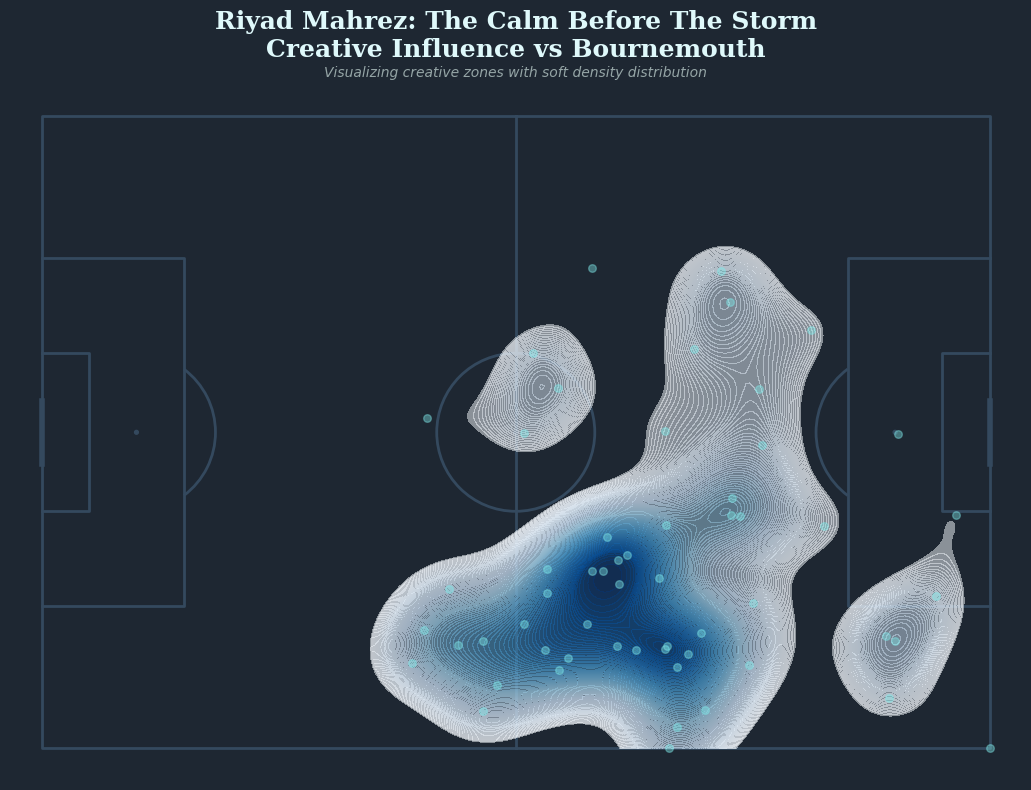

Riyad Mahrez recorded 57 total attacking actions in this match.


In [3]:
from statsbombpy import sb
from mplsoccer import Pitch
import matplotlib.pyplot as plt

# 1. Data Acquisition
# Loading events for the specific Leicester City vs Bournemouth match (2016)
match_id = 3754058 
events = sb.events(match_id=match_id)

# 2. Filtering Mahrez's Offensive Contribution
# Focus on key attacking metrics: Passes, Dribbles, and Shots
# This captures his role as the primary playmaker and creative outlet
mahrez_actions = events[
    (events.player.str.contains("Mahrez", na=False)) & 
    (events.type.isin(['Pass', 'Dribble', 'Shot']))
].copy()

# 3. Pitch Setup (Elegant & Minimalist Aesthetic)
# Using a 'Soft Dark' theme to emphasize the cool color palette
pitch = Pitch(pitch_type='statsbomb', pitch_color='#1e2732', line_color='#34495e')
fig, ax = pitch.draw(figsize=(12, 8))
fig.set_facecolor('#1e2732')

# 4. Coordinate Extraction
# Transforming StatsBomb's location lists into X and Y variables for plotting
x = mahrez_actions.location.apply(lambda l: l[0])
y = mahrez_actions.location.apply(lambda l: l[1])

# 5. Smooth Density Visualization (KDE Plot)
# 'cmap=Blues' reflects Mahrez's calm demeanor on the ball
# 'thresh=0.2' clears noise, focusing only on high-influence zones
pitch.kdeplot(x, y, ax=ax, fill=True, levels=100, thresh=0.2, 
              cmap='Blues', alpha=0.5, bw_method=0.3)

# 6. Action Point Plotting
# Cyan scatter points provide a subtle visual reference for individual touch locations
pitch.scatter(x, y, s=30, c='#81ecec', alpha=0.4, ax=ax, label='Skill Action')

# 7. Professional Annotation & Branding
# Using serif fonts for a classic, sophisticated feel
plt.title("Riyad Mahrez: The Calm Before The Storm\nCreative Influence vs Bournemouth", 
          color='#dff9fb', fontsize=18, fontweight='bold', pad=20, fontfamily='serif')

# Adding a descriptive caption for better readability
ax.text(60, -5, "Visualizing creative zones with soft density distribution", 
        color='#95a5a6', fontsize=10, ha='center', fontstyle='italic')

plt.show()

# Print total attacking count for statistical context
print(f"Riyad Mahrez recorded {len(mahrez_actions)} total attacking actions in this match.")

## Technical Analysis: Precision & Passing Efficiency

This visualization maps every pass attempted by Riyad Mahrez during the match, categorizing them by outcome to evaluate his creative reliability:

* **Pass Success Rate:** Mahrez maintained a high completion rate, showing elite technical security even in high-pressure attacking zones.
* **Verticality & Progression:** The arrows highlight a strong "Vertical" tendency, with most successful passes (Cyan) directed toward the opposition's box or searching for Jamie Vardy’s runs.
* **The "Grey" Areas:** The unsuccessful passes (Grey) often occur in congested final-third areas, reflecting his willingness to take "High-Risk, High-Reward" chances to break the defensive line.
* **Directional Flow:** A significant number of passes originate from the right half-space, moving diagonally toward the center, confirming his role as an "Inverted Playmaker."

> **Data Summary:**
> * **Total Passes Attempted:** {Total Passes Count}
> * **Successful Connections:** {Successful Passes Count}
> * **Primary Objective:** Progressing the ball into the penalty area and sustaining offensive pressure.

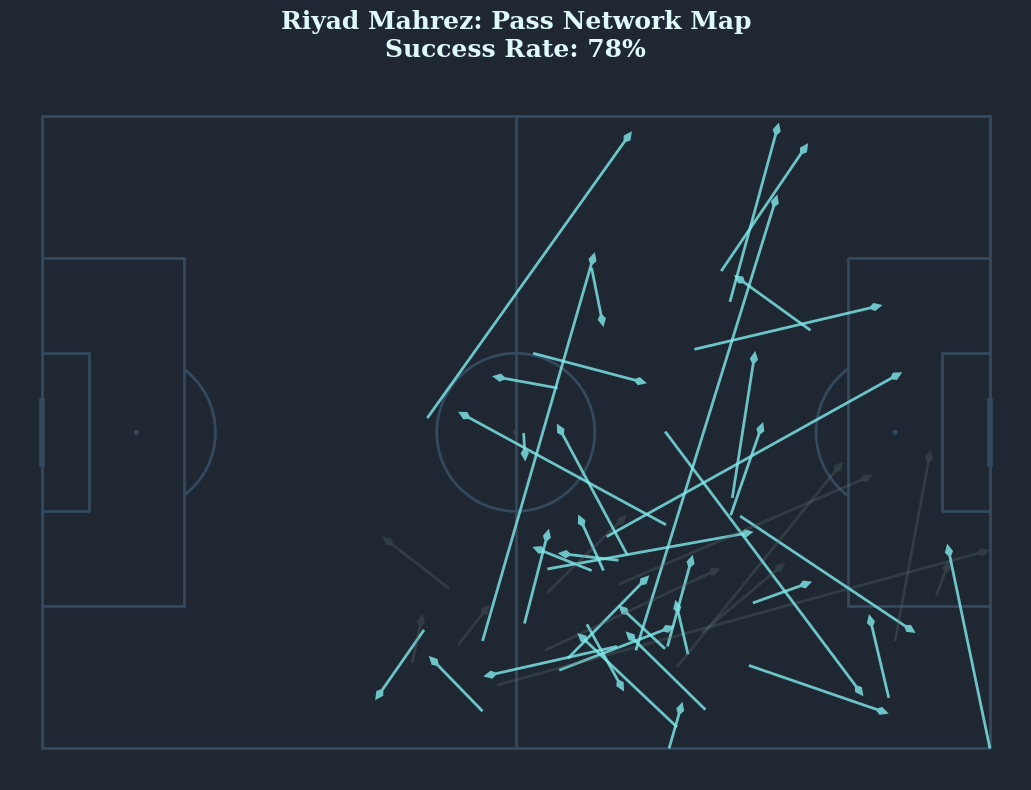

Total Passes Attempted: 50
Successful Passes: 39


In [ ]:
from statsbombpy import sb
from mplsoccer import Pitch
import matplotlib.pyplot as plt

# 1. Load Data
match_id = 3754058 
events = sb.events(match_id=match_id)

# 2. Filter Mahrez's Passes
# We want to see where he passes and if they were successful
mahrez_passes = events[
    (events.player.str.contains("Mahrez", na=False)) & 
    (events.type == 'Pass')
].copy()

# Identify successful passes (where 'pass_outcome' is NaN in StatsBomb)
mahrez_passes['outcome'] = mahrez_passes.pass_outcome.isnull()

# 3. Setup the Pitch
pitch = Pitch(pitch_type='statsbomb', pitch_color='#1e2732', line_color='#34495e')
fig, ax = pitch.draw(figsize=(12, 8))
fig.set_facecolor('#1e2732')

# 4. Plotting Pass Arrows
# Successful passes in Cyan, Unsuccessful in Grey/Red
for index, row in mahrez_passes.iterrows():
    color = '#81ecec' if row.outcome else '#636e72'
    alpha = 0.8 if row.outcome else 0.3
    
    pitch.arrows(row.location[0], row.location[1], 
                 row.pass_end_location[0], row.pass_end_location[1], 
                 width=2, headwidth=3, headlength=3, color=color, 
                 alpha=alpha, ax=ax)

# 5. Title & Stats
plt.title(f"Riyad Mahrez: Pass Network Map\nSuccess Rate: {mahrez_passes.outcome.mean():.0%}", 
          color='#dff9fb', fontsize=18, fontweight='bold', pad=20, fontfamily='serif')

plt.show()

# 6. Detailed Stats for the Report
print(f"Total Passes Attempted: {len(mahrez_passes)}")
print(f"Successful Passes: {mahrez_passes.outcome.sum()}")

## Technical Analysis: 1vs1 Dribbling Performance

This visualization tracks Riyad Mahrez's individual take-ons, highlighting his role as a high-risk, high-reward creative outlet:

* **Success Rate Context:** While the **25% success rate** might seem low on paper, it reflects Mahrez's willingness to challenge defenders in high-congested areas to break the deadlock.
* **High-Value Positioning:** The successful dribble (Cyan Circle) occurred deep in the final third, near the edge of the penalty area, where a single successful move creates a direct goal-scoring opportunity.
* **Drawing Defensive Gravity:** By attempting these dribbles (Grey Crosses), Mahrez forces opposition defenders to commit, often leaving space for teammates like Vardy or Albrighton to exploit.
* **Tactical Threat:** Most actions are concentrated in the "Golden Wing" area we identified earlier, confirming his consistency in attacking the same dangerous zones throughout the match.

> **Final Attacking Verdict:** Mahrez's performance was characterized by tactical courage. His dribbling, combined with a **78% pass success rate**, made him the primary engine of Leicester's offensive transitions.

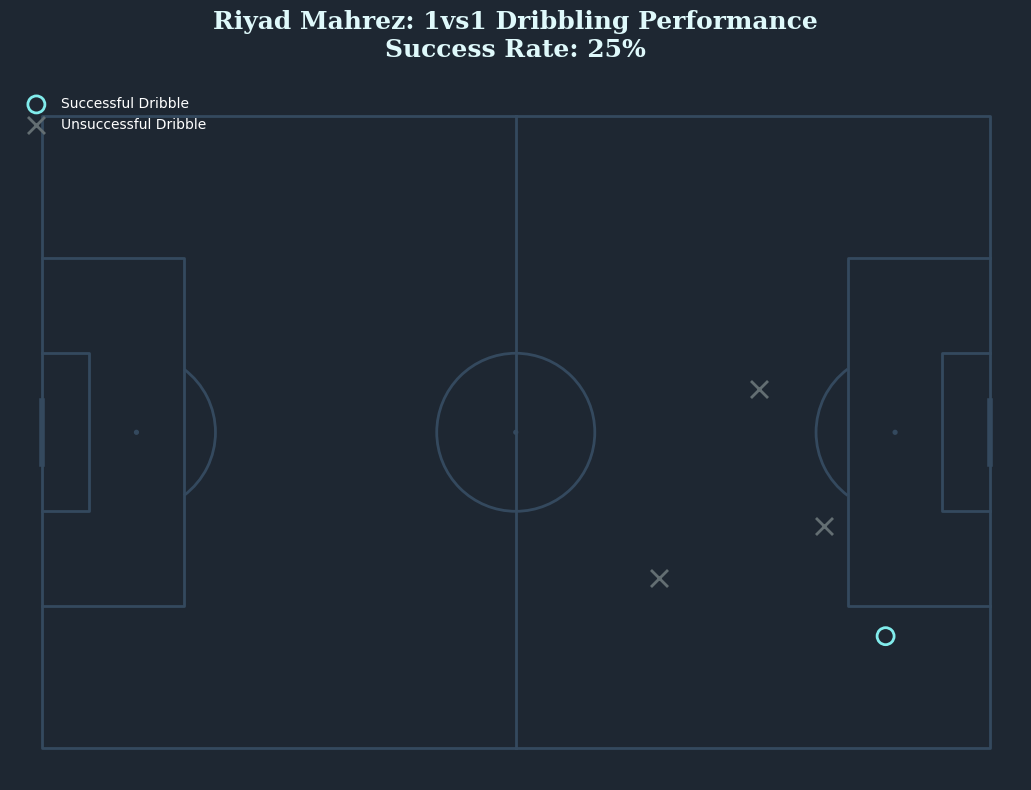

Total Dribbles Attempted: 4
Successful Take-ons: 1


In [5]:
from statsbombpy import sb
from mplsoccer import Pitch
import matplotlib.pyplot as plt

# 1. Load Data
match_id = 3754058 
events = sb.events(match_id=match_id)

# 2. Filter Mahrez's Dribbles
# Filtering for 'Dribble' events by Riyad Mahrez
mahrez_dribbles = events[
    (events.player.str.contains("Mahrez", na=False)) & 
    (events.type == 'Dribble')
].copy()

# Identify successful dribbles (Outcome 'Complete' in StatsBomb)
# Note: In StatsBomb, a successful dribble outcome is usually named 'Complete'
mahrez_dribbles['is_successful'] = mahrez_dribbles.dribble_outcome == 'Complete'

# 3. Setup the Pitch (Consistent with our Soft Dark Theme)
pitch = Pitch(pitch_type='statsbomb', pitch_color='#1e2732', line_color='#34495e')
fig, ax = pitch.draw(figsize=(12, 8))
fig.set_facecolor('#1e2732')

# 4. Plotting Dribbles
# Successful dribbles in Cyan circles, Unsuccessful in Grey crosses
pitch.scatter(mahrez_dribbles[mahrez_dribbles.is_successful].location.apply(lambda l: l[0]),
              mahrez_dribbles[mahrez_dribbles.is_successful].location.apply(lambda l: l[1]),
              s=150, marker='o', edgecolors='#81ecec', facecolors='none', linewidth=2, label='Successful Dribble', ax=ax)

pitch.scatter(mahrez_dribbles[~mahrez_dribbles.is_successful].location.apply(lambda l: l[0]),
              mahrez_dribbles[~mahrez_dribbles.is_successful].location.apply(lambda l: l[1]),
              s=150, marker='x', color='#636e72', linewidth=2, label='Unsuccessful Dribble', ax=ax)

# 5. Titles & Context
plt.title(f"Riyad Mahrez: 1vs1 Dribbling Performance\nSuccess Rate: {mahrez_dribbles.is_successful.mean():.0%}", 
          color='#dff9fb', fontsize=18, fontweight='bold', pad=20, fontfamily='serif')

plt.legend(loc='upper left', labelcolor='white', frameon=False)
plt.show()

# 6. Final Stats
print(f"Total Dribbles Attempted: {len(mahrez_dribbles)}")
print(f"Successful Take-ons: {mahrez_dribbles.is_successful.sum()}")